# PERGUNTA 6

# Porte da empresa e salário.

Importando as Blibliotecas **pandas, numpy e matplotlib.pylot**

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Criando **FUNÇÃO** para carregar um arquivo **csv**

In [12]:
def carregar_banco_csv(caminho):
    return pd.read_csv(caminho)
    pass

Puxando a **FUNÇÃO** através da **VARIÁVEL**, e retornando o **BANCO DE DADOS**

In [13]:
df = carregar_banco_csv(
    r"C:\Users\User\Desktop\BECKUP - PALMEIRAS\CAIXAVERSO - ADA\AULAS PRESENCIAIS\4 - TECNICAS DE PROGRAMAÇÃO I (PY) - DE 12-05-2026 A 26-05-2026\PROJETO\salario_ciencia_dados.csv"
)
df.head()

,cargo,nivel_experiencia,tipo_contrato,modalidade,ano,pais_residencia,salario_moeda_corrente,moeda_corrente,salario_usd,pais_empresa,porte_empresa
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium


# Empresas grandes (L), médias (M) ou pequenas (S) pagam mais?

Comandos para Retornar a **Média Salarial Geral** e **Média em cada porte do Tamanho da Empresa**

In [14]:
# Média salarial geral
media_geral = round(df["salario_usd"].mean(), 2)
print(f"Média salarial geral de todos os funcionários: U$ {media_geral}\n")
# Média salarial por tamanho da empresa
salario_por_tamanho_empresa = df.groupby("porte_empresa")["salario_usd"].mean().round(2).sort_values()
print(salario_por_tamanho_empresa)

Média salarial geral de todos os funcionários: U$ 145560.56

porte_empresa
Small      87687.46
Large     120638.40
Medium    149659.39
Name: salario_usd, dtype: float64


# A diferença é maior em algum nível de experiência específico?

Comandos para comparação **TAMANHO x EXPERIÊNCIA.** Trazendo também o resultado da média por **TAMANHO** independente da experiência

In [10]:
# Média salarial geral
media_geral = round(df["salario_usd"].mean(), 2)
print(f"Média salarial geral de todos os funcionários: U$ {media_geral}\n")
# Média salarial por nível de experiência e tamanho da empresa
progressao_por_nivel_tamanho = df.groupby(["porte_empresa", "nivel_experiencia"])["salario_usd"].mean().unstack().round(2)
# Adicionar coluna com a média salarial do nivel
progressao_por_nivel_tamanho["media_tamanho"] = salario_por_tamanho_empresa
progressao_por_nivel_tamanho

Média salarial geral de todos os funcionários: U$ 145560.56

experience_level  Entry-level  Executive-level  Mid-level  Senior-level  \
company_size                                                              
Large                74603.33        187993.90  100625.17     150556.66   
Medium               89223.05        190563.40  123303.99     163532.47   
Small                68485.94        169172.38   73769.65     110273.73   

experience_level  media_tamanho  
company_size                     
Large                 120638.40  
Medium                149659.39  
Small                  87687.46  


Comando para Visualização em **GRÁFICO** com o resultado das variáveis calculadas

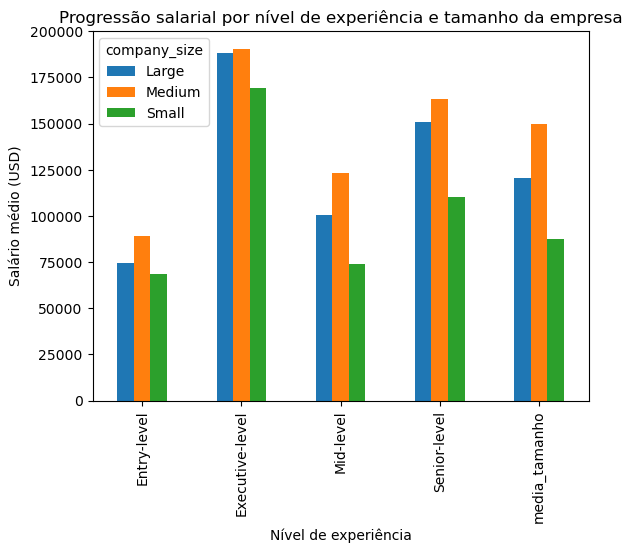

In [15]:
progressao_por_nivel_tamanho.T.plot(kind="bar")
plt.title("Progressão salarial por nível de experiência e tamanho da empresa")
plt.ylabel("Salário médio (USD)")
plt.xlabel("Nível de experiência")
plt.show()